
<style>
.jp-Notebook .jp-MarkdownCell,
.text_cell_render {
    font-size: 14px;
    line-height: 1.38;
}
.jp-CodeCell .cm-editor,
.jp-CodeCell pre,
.code_cell .CodeMirror {
    font-size: 13px !important;
    line-height: 1.30 !important;
}
</style>

# ECON 422: Macroeconomics & Machine Learning
## Tree-based Methods — Hands-on Practice

We use one simulated macroeconomic data set to practice three ideas:

- **CART:** recursively split the predictor space;
- **Random forest:** fit randomized trees in parallel and average;
- **Gradient boosting:** fit trees sequentially to the remaining prediction gap.

The goal is to connect the code to the logic in the class note rather than to build a large forecasting exercise.


### Setup

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error</pre>

In [ ]:
# Type the Setup code here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error


### Practice 1 — Create a nonlinear macroeconomic pattern

The data-generating process follows the motivating idea from the note: GDP growth changes across local regions of unemployment and the credit spread.

We split the observations into an **estimation sample** and a **test sample**.
<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">rng = np.random.default_rng(14)
n = 140

unemployment = rng.uniform(3.5, 9.0, n)
credit_spread = rng.uniform(0.5, 4.0, n)
inflation = rng.normal(2.5, 0.8, n)
interest_rate = rng.normal(3.0, 0.9, n)

growth = np.where(
    unemployment &lt; 6.0,
    4.0,
    np.where(credit_spread &lt; 2.25, 2.0, -3.0)
)
growth = growth + 0.25 * (inflation - 2.5) + rng.normal(0, 0.65, n)

X = pd.DataFrame({
    &quot;unemployment&quot;: unemployment,
    &quot;credit_spread&quot;: credit_spread,
    &quot;inflation&quot;: inflation,
    &quot;interest_rate&quot;: interest_rate
})
y = pd.Series(growth, name=&quot;gdp_growth&quot;)

X_est, X_test, y_est, y_test = train_test_split(
    X, y, test_size=0.25, random_state=14
)

X.head()</pre>

In [4]:
# Type Practice 1 here.
rng = np.random.default_rng(14)
n = 140

unemployment = rng.uniform(3.5, 9.0, n)
credit_spread = rng.uniform(0.5, 4.0, n)
inflation = rng.normal(2.5, 0.8, n)
interest_rate = rng.normal(3.0, 0.9, n)

growth = np.where(
    unemployment < 6.0,
    4.0,
    np.where(credit_spread < 2.25, 2.0, -3.0)
)
growth = growth + 0.25 * (inflation - 2.5) + rng.normal(0, 0.65, n)

X = pd.DataFrame({
    'unemployment': unemployment,
    'credit_spread': credit_spread,
    'inflation': inflation,
    'interest_rate': interest_rate
})
y = pd.Series(growth, name='gdp_growth')

X_est, X_test, y_est, y_test = train_test_split(X, y, test_size=0.25, random_state=14)

X.head()

,unemployment,credit_spread,inflation,interest_rate
0,8.070408,2.693230,3.534728,3.389645
1,5.485207,0.596947,3.594059,2.646861
2,7.365066,0.666917,3.070287,3.301342
3,8.230653,1.030522,2.108843,3.347870
4,7.027246,2.046786,3.859066,5.414832



### Practice 2 — CART: learn local regions

At a node \(A\), CART chooses the predictor-cutoff pair that minimizes

$$
\operatorname{SSE}_{A}(j,s)
=
\sum_{i\in R_L(A;j,s)}
\left(Y_i-\bar{Y}_{L}\right)^2
+
\sum_{i\in R_R(A;j,s)}
\left(Y_i-\bar{Y}_{R}\right)^2.
$$

Here we restrict the tree to depth 2 so the learned local regions are easy to inspect.
<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">cart = DecisionTreeRegressor(
    max_depth=2,
    min_samples_leaf=8,
    random_state=14
)
cart.fit(X_est, y_est)

pred_cart = cart.predict(X_test)
mse_cart = mean_squared_error(y_test, pred_cart)

print(&quot;CART test MSE:&quot;, round(mse_cart, 3))

plt.figure(figsize=(11, 5))
plot_tree(
    cart,
    feature_names=X.columns,
    filled=False,
    rounded=True,
    fontsize=9
)
plt.show()</pre>

CART test MSE: 0.54


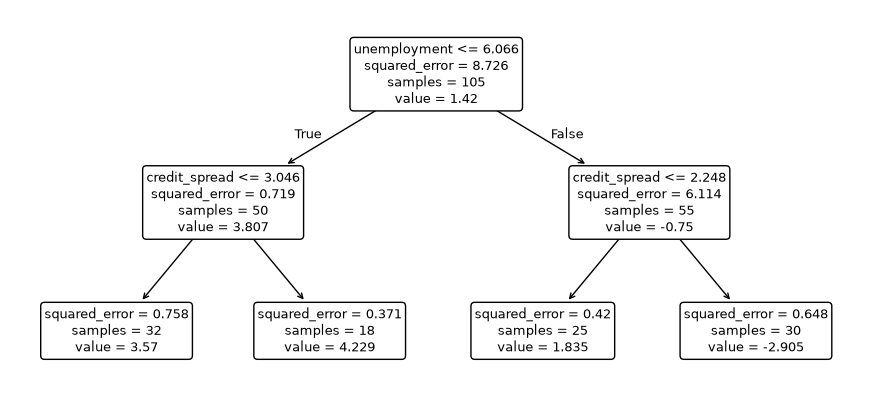

In [5]:
# Type Practice 2 here.
cart = DecisionTreeRegressor(max_depth=2, min_samples_leaf = 8, random_state=14)
cart.fit(X_est, y_est)

pred_cart = cart.predict(X_test)
mse_cart = mean_squared_error(y_test, pred_cart)

print("CART test MSE:", round(mse_cart, 3))

plt.figure(figsize = (11,5))
plot_tree(cart, feature_names=X.columns, filled=False, rounded=True, fontsize=9)
plt.show()


### Practice 3 — Random forest: parallel trees + average

A random forest combines many randomized trees:

$$
\widehat f_{\mathrm{RF}}(X)
=
\frac{1}{B}
\sum_{b=1}^{B}
\widehat f_b(X).
$$

The code also prints the first five individual-tree predictions for one new quarter. They differ because the trees use bootstrap samples and random predictor subsets.
<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">rf = RandomForestRegressor(
    n_estimators=200,
    max_features=2,
    min_samples_leaf=4,
    bootstrap=True,
    oob_score=True,
    random_state=14
)
rf.fit(X_est, y_est)

pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, pred_rf)

new_q = pd.DataFrame({
    &quot;unemployment&quot;: [6.5],
    &quot;credit_spread&quot;: [2.2],
    &quot;inflation&quot;: [2.5],
    &quot;interest_rate&quot;: [3.0]
})

first_five = np.array([
    tree.predict(new_q.to_numpy())[0]
    for tree in rf.estimators_[:5]
])

print(&quot;First five tree predictions:&quot;, np.round(first_five, 2))
print(&quot;Forest prediction:&quot;, round(rf.predict(new_q)[0], 2))
print(&quot;Random forest test MSE:&quot;, round(mse_rf, 3))
print(&quot;OOB R^2:&quot;, round(rf.oob_score_, 3))</pre>

In [6]:
# Type Practice 3 here.
rf = RandomForestRegressor(
    n_estimators=200,
    max_features=2,
    min_samples_leaf=4,
    bootstrap=True,
    oob_score=True,
    random_state=14
)
rf.fit(X_est, y_est)

pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, pred_rf)

new_q = pd.DataFrame({
    "unemployment": [6.5],
    "credit_spread": [2.2],
    "inflation": [2.5],
    "interest_rate": [3.0]
})

first_five = np.array([
    tree.predict(new_q.to_numpy())[0]
    for tree in rf.estimators_[:5]
])

print("First five tree predictions:", np.round(first_five, 2))
print("Forest prediction:", round(rf.predict(new_q)[0], 2))
print("Random forest test MSE:", round(mse_rf, 3))
print("OOB R^2:", round(rf.oob_score_, 3))

First five tree predictions: [ 1.71  2.28 -2.47  1.84 -2.67]
Forest prediction: 1.07
Random forest test MSE: 0.804
OOB R^2: 0.849



### Practice 4 — Gradient boosting: sequential correction

Under squared-error loss, the remaining gap at round \(m\) is

$$
r_{im}
=
Y_i-\widehat f_{m-1}(X_i),
$$

and the model is updated by

$$
\widehat f_m(X)
=
\widehat f_{m-1}(X)
+
\nu h_m(X).
$$

The staged predictions below show how the prediction for the same new quarter changes as corrective trees are added.
<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">gb = GradientBoostingRegressor(
    n_estimators=60,
    learning_rate=0.05,
    max_depth=2,
    random_state=14
)
gb.fit(X_est, y_est)

pred_gb = gb.predict(X_test)
mse_gb = mean_squared_error(y_test, pred_gb)

staged_new_q = [
    pred[0] for pred in gb.staged_predict(new_q)
]

for m in [1, 10, 30, 60]:
    print(
        f&quot;After {m:&gt;2} boosting rounds:&quot;,
        round(staged_new_q[m - 1], 2)
    )

print(&quot;Gradient boosting test MSE:&quot;, round(mse_gb, 3))</pre>

In [7]:
# Type Practice 4 here.
gb = GradientBoostingRegressor(
    n_estimators=60,
    learning_rate=0.05,
    max_depth=2,
    random_state=14
)
gb.fit(X_est, y_est)

pred_gb = gb.predict(X_test)
mse_gb = mean_squared_error(y_test, pred_gb)

staged_new_q = [
    pred[0] for pred in gb.staged_predict(new_q)
]

for m in [1, 10, 30, 60]:
    print(f"After {m:>2} boosting rounds:", round(staged_new_q[m-1], 2)
    )
print("Gradient boosting test MSE:", round(mse_gb, 3))

After  1 boosting rounds: 1.44
After 10 boosting rounds: 1.59
After 30 boosting rounds: 1.74
After 60 boosting rounds: 1.77
Gradient boosting test MSE: 0.499



### Practice 5 — Compare test performance

The three methods use trees differently:

- CART: **split**;
- Random forest: **parallel trees + average**;
- Gradient boosting: **sequential trees + correction**.

Use the same test sample and the same mean squared error for a direct comparison.
<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">scores = {
    &quot;CART&quot;: mse_cart,
    &quot;Random forest&quot;: mse_rf,
    &quot;Gradient boosting&quot;: mse_gb
}

for name, value in scores.items():
    print(f&quot;{name:18s}: {value:.3f}&quot;)

best_method = min(scores, key=scores.get)
print(&quot;\nLowest test MSE:&quot;, best_method)</pre>

In [8]:
# Type Practice 5 here.
scores = {
    "CART": mse_cart,
    "Random forest": mse_rf,
    "Gradient boosting": mse_gb
}

for name, value in scores.items():
    print(f"{name:18s}: {value:.3f}")

best_method = min(scores, key=scores.get)
print("\nLowest test MSE:", best_method)

CART              : 0.540
Random forest     : 0.804
Gradient boosting : 0.499

Lowest test MSE: Gradient boosting



## Exercise

Copy and paste the DGP code from **'(Sep14) Exercise' on Canvas** into the code cell below.  
The DGP should create `X_ex` and `y_ex`.

Using the same estimation/test split, fit:

1. one CART model;
2. one random forest;
3. one gradient boosting model.

Then compare their **test MSE** and report the method with the smallest value.


In [3]:
# Copy and paste the DGP code here.
rng = np.random.default_rng(11)
n_ex = 160

unemployment_ex = rng.uniform(3.5, 9.0, n_ex)
credit_spread_ex = rng.uniform(0.5, 4.0, n_ex)
inflation_ex = rng.normal(2.4, 0.9, n_ex)
interest_rate_ex = rng.normal(3.1, 1.0, n_ex)

growth_ex = np.where(
    unemployment_ex < 5.8,
    3.5,
    np.where(credit_spread_ex < 2.2, 1.2, -2.8)
)
growth_ex = (
    growth_ex
    + 0.30 * (inflation_ex - 2.4)
    + rng.normal(0, 0.75, n_ex)
)

X_ex = pd.DataFrame({
    "unemployment": unemployment_ex,
    "credit_spread": credit_spread_ex,
    "inflation": inflation_ex,
    "interest_rate": interest_rate_ex
})
y_ex = pd.Series(growth_ex, name="gdp_growth")

### Exercise code

Fill in the four blanks.

### DGP

In [ ]:
# Copy and paste the DGP code from '(Sep14) Exercise' in Quizzes.
# The DGP should create X_ex and y_ex.


### Rubric / hints

- **CART:** use a shallow tree.  
  *Hint:* the class practice used a depth that allows a root split plus one additional split.

- **Random forest:** use many trees rather than one tree.  
  *Hint:* the class practice used a few hundred trees.

- **Gradient boosting:** use a small positive learning rate.  
  *Hint:* use the same learning rate as in the class practice.

- **Common test MSE:** calculate mean squared error for all three methods on the same test sample.

- **Model selection:** choose the key in the MSE dictionary with the smallest value.  
  *Hint:* `min(dictionary, key=...)` can select the key associated with the smallest dictionary value.


In [9]:
X_est_ex, X_test_ex, y_est_ex, y_test_ex = train_test_split(
    X_ex, y_ex, test_size=0.30, random_state=11
)

cart_ex = DecisionTreeRegressor(
    max_depth=2,
    min_samples_leaf=8,
    random_state=11
)
cart_ex.fit(X_est_ex, y_est_ex)

rf_ex = RandomForestRegressor(
    n_estimators=200,
    max_features=2,
    min_samples_leaf=4,
    random_state=11
)
rf_ex.fit(X_est_ex, y_est_ex)

gb_ex = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=11
)
gb_ex.fit(X_est_ex, y_est_ex)

mse_ex = {
    "CART": mean_squared_error(y_test_ex, cart_ex.predict(X_test_ex)),
    "Random forest": mean_squared_error(y_test_ex, rf_ex.predict(X_test_ex)),
    "Gradient boosting": mean_squared_error(y_test_ex, gb_ex.predict(X_test_ex))
}

best_ex = min(mse_ex, key=mse_ex.get)

print("Test MSE:", mse_ex)
print("Best method:", best_ex)

Test MSE: {'CART': 0.6336891409314229, 'Random forest': 0.9005475889136649, 'Gradient boosting': 0.6383451564521248}
Best method: CART
